# Least-Squares Regression

## Fitting a Model With Fewer Unknowns Than Data Points

Given $m$ data points $(x_k, y_k)$ that may contain noise, we look for a
model of the form

$$
\hat{y}(x) \;=\; \sum_{i=1}^{n} \beta_i\, f_i(x)
$$

with $n$ chosen basis functions $f_i$ and $n$ unknown coefficients $\beta_i$.

**The defining feature of regression is that we use *fewer* coefficients than
data points** ($n < m$). Because the model has fewer degrees of freedom than
the data, it generally **cannot pass through every point**. We compromise:
choose the $\beta_i$ that minimise the sum of squared residuals

$$
E(\beta_1, \ldots, \beta_n) \;=\; \sum_{k=1}^{m}\bigl(y_k - \hat{y}(x_k)\bigr)^2
$$

| $n$ vs $m$ | Result | Interpretation |
|------------|--------|----------------|
| $n < m$ | True regression — residuals exist | Smooths through noise |
| $n = m$ | All residuals = 0 — interpolation! | Curve passes through every point |
| $n > m$ | Underdetermined — infinitely many fits | Reject (or use regularisation) |

The normal equations $\mathbf{A}^\top \mathbf{A}\,\vec{\beta} = \mathbf{A}^\top \mathbf{Y}$
follow from setting $\partial E / \partial \beta_i = 0$ (or, geometrically,
from requiring the residual vector to be orthogonal to the column space of $\mathbf{A}$).

---


## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# House-style palette
COLORS = ["#94a3b8", "#64748b", "#7c3aed", "#2563eb", "#ea580c"]


## 2 — Generating Noisy Data

We work with synthetic data so that we always know the **true** underlying
function and can judge the fit honestly. The "true" curve is

$$
y_{\text{true}}(x) \;=\; 0.3\,x^2 - 0.8\,x + 2
$$

Measurements are $y_k = y_{\text{true}}(x_k) + \varepsilon_k$ with Gaussian
noise $\varepsilon_k \sim \mathcal{N}(0, \sigma^2)$.

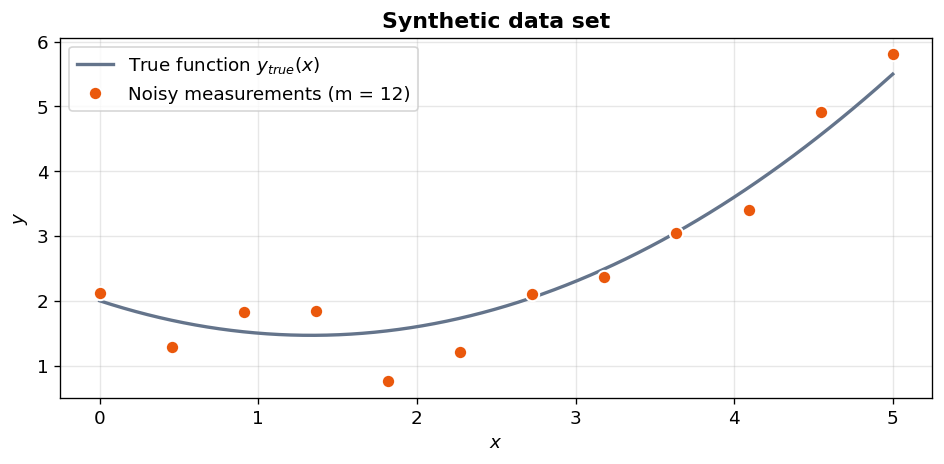

In [3]:
rng = np.random.default_rng(seed=42)


def true_function(x):
    return 0.3 * x**2 - 0.8 * x + 2.0


def make_noisy_data(n_points, x_range=(0.0, 5.0), sigma=0.4):
    x = np.linspace(*x_range, n_points)
    y = true_function(x) + rng.normal(0.0, sigma, size=n_points)
    return x, y


x_data, y_data = make_noisy_data(n_points=12)

# Quick look
fig, ax = plt.subplots(figsize=(8, 4))
x_fine = np.linspace(0, 5, 200)
ax.plot(x_fine, true_function(x_fine), color=COLORS[1], lw=2,
        label="True function $y_{true}(x)$", zorder=2)
ax.plot(x_data, y_data, "o", color=COLORS[4], markersize=8,
        markeredgecolor="white", markeredgewidth=1.2,
        label=f"Noisy measurements (m = {len(x_data)})", zorder=5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Synthetic data set", fontweight="bold")
ax.legend()
fig.tight_layout()
plt.show()


## 3 — The Least-Squares Framework

### Building the design matrix

Stack the basis functions evaluated at the data points:

$$
\mathbf{A} \;=\;
\begin{pmatrix}
f_1(x_1) & f_2(x_1) & \cdots & f_n(x_1) \\
f_1(x_2) & f_2(x_2) & \cdots & f_n(x_2) \\
\vdots   & \vdots   & \ddots & \vdots   \\
f_1(x_m) & f_2(x_m) & \cdots & f_n(x_m)
\end{pmatrix}
\qquad (m \times n)
$$

Then $\hat{\mathbf{Y}} = \mathbf{A}\vec{\beta}$ and the residual vector is
$\vec{e} = \mathbf{Y} - \mathbf{A}\vec{\beta}$.

### Solving the normal equations

The minimiser of $E = \|\vec{e}\|^2$ is

$$
\boxed{\;\;\vec{\beta} \;=\; (\mathbf{A}^\top \mathbf{A})^{-1}\, \mathbf{A}^\top \mathbf{Y}\;\;}
$$


In [4]:
def design_matrix_polynomial(x, degree):
    "Polynomial design matrix with columns 1, x, x^2, ..., x^degree."
    x = np.asarray(x, dtype=float)
    return np.vander(x, degree + 1, increasing=True)


def least_squares_fit(A, y):
    "Solve the normal equations A^T A beta = A^T y."
    AtA = A.T @ A
    Aty = A.T @ y
    beta = np.linalg.solve(AtA, Aty)
    return beta


def evaluate_model(A, beta):
    "Compute the predicted values y_hat = A beta."
    return A @ beta


## 4 — Linear Regression: Residuals Made Visible

Start with the simplest model: a straight line $\hat{y}(x) = \beta_1 + \beta_2 x$
(so $n = 2$ unknowns). With $m = 12$ noisy data points, the line cannot pass
through every point — the **residuals** $e_k = y_k - \hat{y}(x_k)$ tell us by
how much each prediction misses.

Fitted model:     y_hat(x) = +0.7085  +0.7394 * x
Number of data points  m = 12
Number of parameters   n = 2
Sum of squared errors  E = 9.1216
Mean squared error       = 0.7601


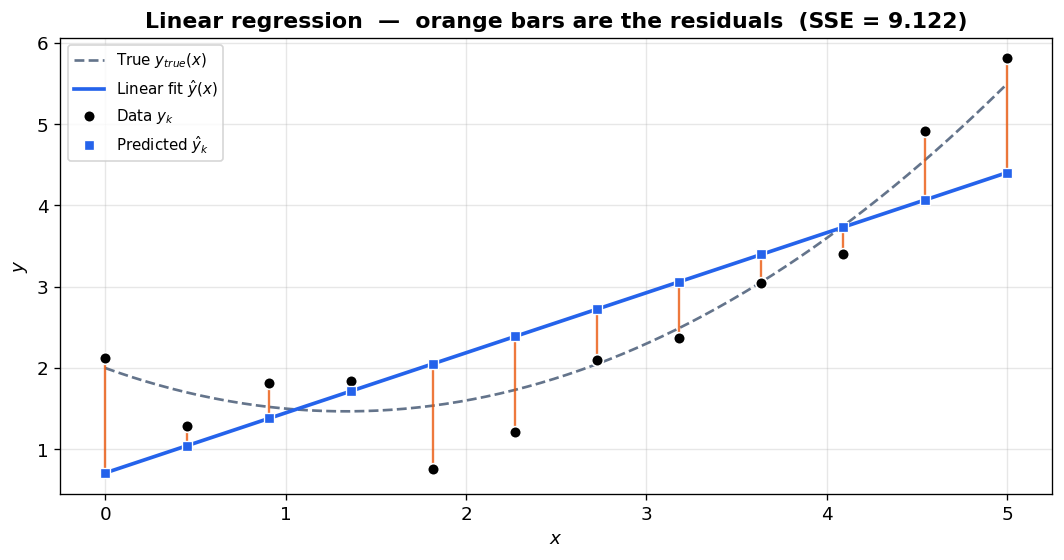

In [5]:
# Linear fit: 2 parameters, 12 data points  ->  10 degrees of freedom remain
A = design_matrix_polynomial(x_data, degree=1)
beta = least_squares_fit(A, y_data)
y_hat = evaluate_model(A, beta)
residuals = y_data - y_hat
SSE = np.sum(residuals ** 2)

print(f"Fitted model:     y_hat(x) = {beta[0]:+.4f}  {beta[1]:+.4f} * x")
print(f"Number of data points  m = {len(x_data)}")
print(f"Number of parameters   n = {len(beta)}")
print(f"Sum of squared errors  E = {SSE:.4f}")
print(f"Mean squared error       = {SSE / len(x_data):.4f}")

# Plot data, fit, and residuals as vertical lines
x_fine = np.linspace(0, 5, 200)
A_fine = design_matrix_polynomial(x_fine, degree=1)
y_fine = evaluate_model(A_fine, beta)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x_fine, true_function(x_fine), color=COLORS[1], lw=1.6,
        ls="--", label="True $y_{true}(x)$", zorder=2)
ax.plot(x_fine, y_fine, color=COLORS[3], lw=2.2,
        label=r"Linear fit $\hat{y}(x)$", zorder=3)

# Residuals as vertical lines
for xk, yk, yh in zip(x_data, y_data, y_hat):
    ax.plot([xk, xk], [yk, yh], color=COLORS[4], lw=1.4, alpha=0.8, zorder=4)

ax.plot(x_data, y_data, "o", color="black", markersize=7,
        markeredgecolor="white", markeredgewidth=1.0,
        label="Data $y_k$", zorder=5)
ax.plot(x_data, y_hat, "s", color=COLORS[3], markersize=6,
        markeredgecolor="white", markeredgewidth=0.8,
        label=r"Predicted $\hat{y}_k$", zorder=5)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"Linear regression  —  orange bars are the residuals  "
             f"(SSE = {SSE:.3f})", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


## 5 — Why "Squared" Residuals?

The error $E = \sum_k e_k^2$ is the **sum of areas of the squares** with side
length $|e_k|$. Plotting these squares on top of the data gives a
direct geometric picture of what we are minimising.

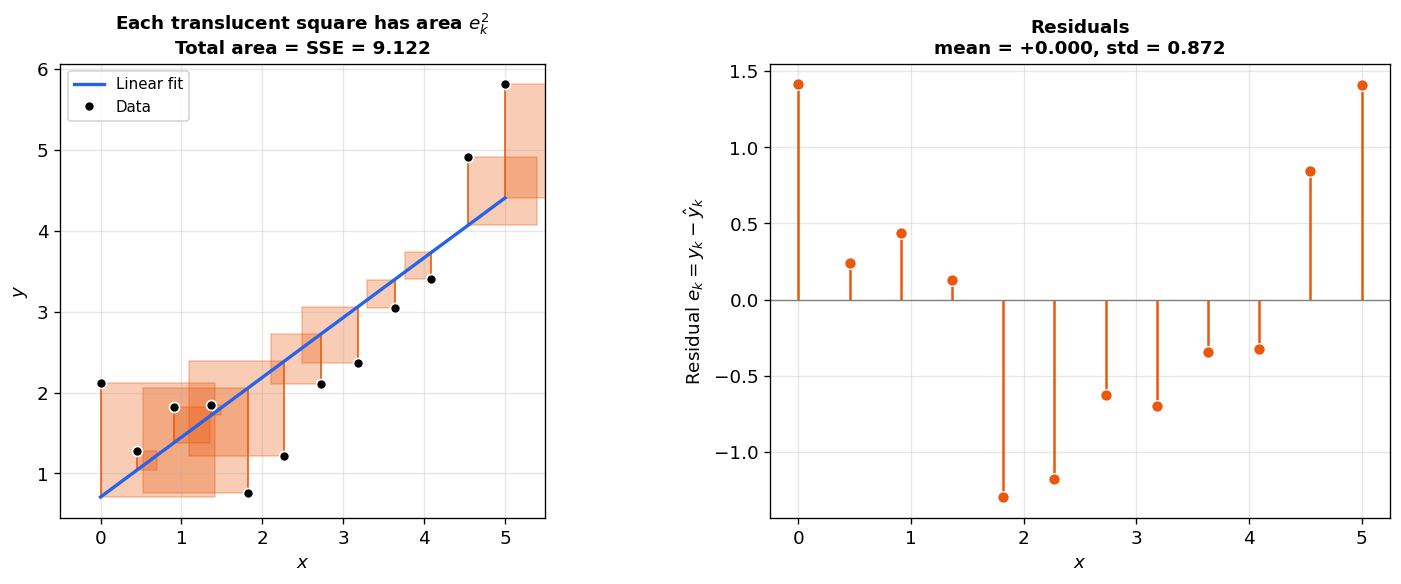

In [6]:
# Reuse the linear fit from Section 4
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [1.4, 1]})

# Left panel: data, fit, and a literal square per residual
ax = axes[0]
ax.set_aspect("equal")  # so a square actually looks square
ax.plot(x_fine, y_fine, color=COLORS[3], lw=2, label="Linear fit", zorder=3)

for xk, yk, ek in zip(x_data, y_data, residuals):
    side = abs(ek)
    # Place the square so one corner sits on the predicted point and the opposite
    # corner reaches the data point (in the y direction).
    if ek >= 0:
        anchor = (xk, yk - side)            # square sits between y_hat and y_data
    else:
        anchor = (xk - side, yk)            # below the fit; place to the left
    sq = patches.Rectangle(anchor, side, side,
                           facecolor=COLORS[4], edgecolor=COLORS[4],
                           alpha=0.30, lw=1)
    ax.add_patch(sq)
    ax.plot([xk, xk], [yk, yk - ek], color=COLORS[4], lw=1.0, alpha=0.9)

ax.plot(x_data, y_data, "o", color="black", markersize=6,
        markeredgecolor="white", markeredgewidth=1.0, label="Data", zorder=5)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(r"Each translucent square has area $e_k^2$"
             "\nTotal area = SSE = " + f"{SSE:.3f}",
             fontweight="bold", fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(-0.5, 5.5)

# Right panel: stem plot of the residuals
ax = axes[1]
markerline, stemlines, baseline = ax.stem(x_data, residuals, basefmt=" ")
plt.setp(stemlines, color=COLORS[4], lw=1.5)
plt.setp(markerline, color=COLORS[4], markersize=7,
         markeredgecolor="white", markeredgewidth=0.8)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("$x$")
ax.set_ylabel("Residual $e_k = y_k - \\hat{y}_k$")
ax.set_title(f"Residuals\nmean = {residuals.mean():+.3f}, "
             f"std = {residuals.std(ddof=0):.3f}",
             fontweight="bold", fontsize=11)

fig.tight_layout()
plt.show()


**A property of least-squares fits with an intercept term:**
the residuals always sum to (very nearly) zero — every positive miss is
balanced by a negative miss. This is *not* a fluke; it follows from the
first row of the normal equations.

## 6 — Polynomial Regression of Different Degrees

Increase $n$ (number of basis functions = polynomial coefficients) and watch
the SSE drop. The data still has $m = 12$ points; only $n$ changes.

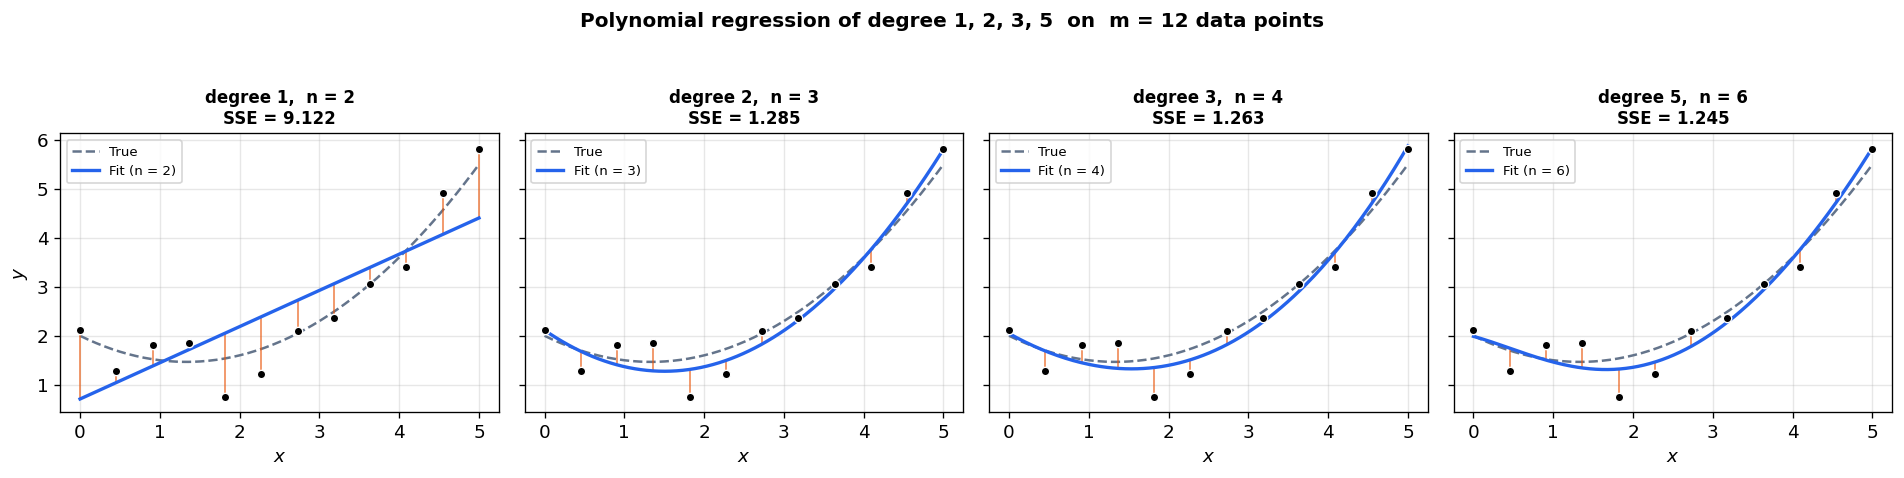

In [7]:
degrees = [1, 2, 3, 5]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)

for ax, deg in zip(axes, degrees):
    A = design_matrix_polynomial(x_data, degree=deg)
    beta = least_squares_fit(A, y_data)
    y_hat = evaluate_model(A, beta)
    SSE = np.sum((y_data - y_hat) ** 2)

    A_fine = design_matrix_polynomial(x_fine, degree=deg)
    y_fine = evaluate_model(A_fine, beta)

    ax.plot(x_fine, true_function(x_fine), color=COLORS[1],
            ls="--", lw=1.5, label="True", zorder=2)
    ax.plot(x_fine, y_fine, color=COLORS[3], lw=2,
            label=f"Fit (n = {deg + 1})", zorder=3)
    for xk, yk, yh in zip(x_data, y_data, y_hat):
        ax.plot([xk, xk], [yk, yh], color=COLORS[4], lw=1.0, alpha=0.7)
    ax.plot(x_data, y_data, "o", color="black", markersize=5,
            markeredgecolor="white", markeredgewidth=0.8, zorder=5)

    ax.set_title(f"degree {deg},  n = {deg + 1}\nSSE = {SSE:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("$x$")
    ax.legend(fontsize=8, loc="upper left")

axes[0].set_ylabel("$y$")
fig.suptitle(f"Polynomial regression of degree 1, 2, 3, 5  on  m = {len(x_data)} data points",
             fontsize=12, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


SSE always decreases (or stays equal) as $n$ grows — the model has more
flexibility. But notice that the degree-2 fit already captures the underlying
structure; the degree-5 fit starts chasing noise.

## 7 — When Regression Becomes Interpolation

Here is the key conceptual point. As long as $n < m$, residuals exist and
SSE > 0. As soon as $n = m$ — that is, as soon as the polynomial has as
many coefficients as we have data points — there is exactly one polynomial
that fits perfectly, and SSE drops to zero.

**At that moment, regression and interpolation are the same thing.**

In [8]:
# Use a smaller data set so we can clearly see the transition
x_small, y_small = make_noisy_data(n_points=6, x_range=(0, 5), sigma=0.4)
m = len(x_small)
print(f"Number of data points:  m = {m}")
print()
print(f"{'n (params)':>11}  {'degree':>7}  {'SSE':>10}")
print("-" * 35)

degrees_to_try = list(range(1, m))   # 1, 2, 3, 4, 5  ->  n = 2, 3, 4, 5, 6
SSEs = []
for deg in degrees_to_try:
    A = design_matrix_polynomial(x_small, degree=deg)
    beta = least_squares_fit(A, y_small)
    y_hat = A @ beta
    sse = float(np.sum((y_small - y_hat) ** 2))
    SSEs.append(sse)
    print(f"{deg + 1:>11d}  {deg:>7d}  {sse:>10.2e}")


Number of data points:  m = 6

 n (params)   degree         SSE
-----------------------------------
          2        1    3.01e+00
          3        2    3.14e-01
          4        3    2.87e-01
          5        4    7.00e-02
          6        5    2.24e-22


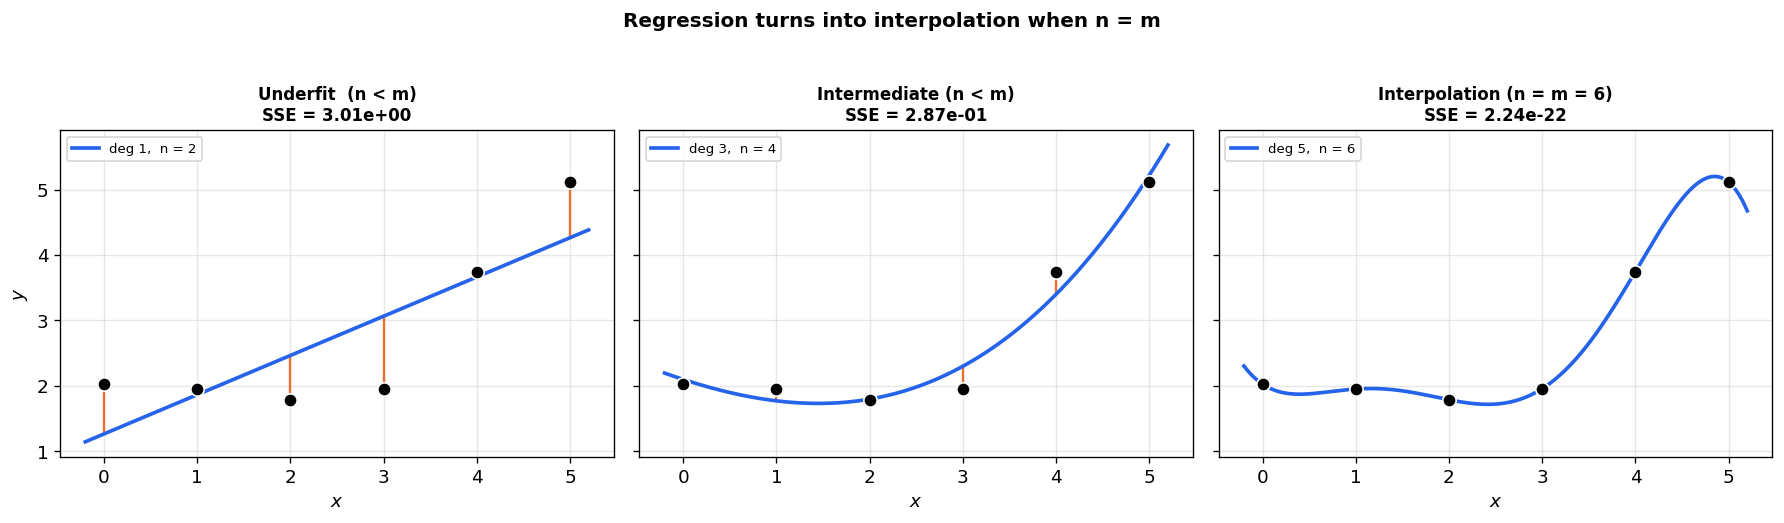


Right panel: residuals are 9.96e-12
...essentially zero (numerical round-off) — the curve really passes through every point.


In [9]:
# Show the three most interesting cases visually
x_fine = np.linspace(-0.2, 5.2, 300)
cases = [(1, "Underfit  (n < m)"),
         (3, "Intermediate (n < m)"),
         (m - 1, f"Interpolation (n = m = {m})")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (deg, title) in zip(axes, cases):
    A = design_matrix_polynomial(x_small, degree=deg)
    beta = least_squares_fit(A, y_small)
    y_hat = A @ beta
    sse = float(np.sum((y_small - y_hat) ** 2))

    A_fine = design_matrix_polynomial(x_fine, degree=deg)
    ax.plot(x_fine, A_fine @ beta, color=COLORS[3], lw=2.2,
            label=f"deg {deg},  n = {deg + 1}", zorder=3)

    for xk, yk, yh in zip(x_small, y_small, y_hat):
        ax.plot([xk, xk], [yk, yh], color=COLORS[4], lw=1.4, alpha=0.85)
    ax.plot(x_small, y_small, "o", color="black", markersize=8,
            markeredgecolor="white", markeredgewidth=1.0, zorder=5)

    ax.set_title(f"{title}\nSSE = {sse:.2e}", fontsize=10, fontweight="bold")
    ax.set_xlabel("$x$")
    ax.legend(fontsize=8, loc="upper left")

axes[0].set_ylabel("$y$")
fig.suptitle("Regression turns into interpolation when n = m",
             fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

print()
A_full = design_matrix_polynomial(x_small, m - 1)
beta_full = least_squares_fit(A_full, y_small)
max_resid = abs(y_small - A_full @ beta_full).max()
print(f"Right panel: residuals are {max_resid:.2e}")
print("...essentially zero (numerical round-off) — the curve really passes through every point.")


## 8 — Choosing Different Basis Functions

The least-squares framework works for *any* set of basis functions $f_i(x)$,
not just monomials. The unknowns $\beta_i$ enter linearly even if the basis
functions themselves are highly nonlinear in $x$.

A common choice when the data shows a saturation or growth pattern is

$$
\hat{y}(x) \;=\; \beta_1 + \beta_2 \,e^{-x/\tau}
$$

with $\tau$ fixed beforehand (otherwise the model is nonlinear in $\beta$ and
the normal equations no longer apply directly).

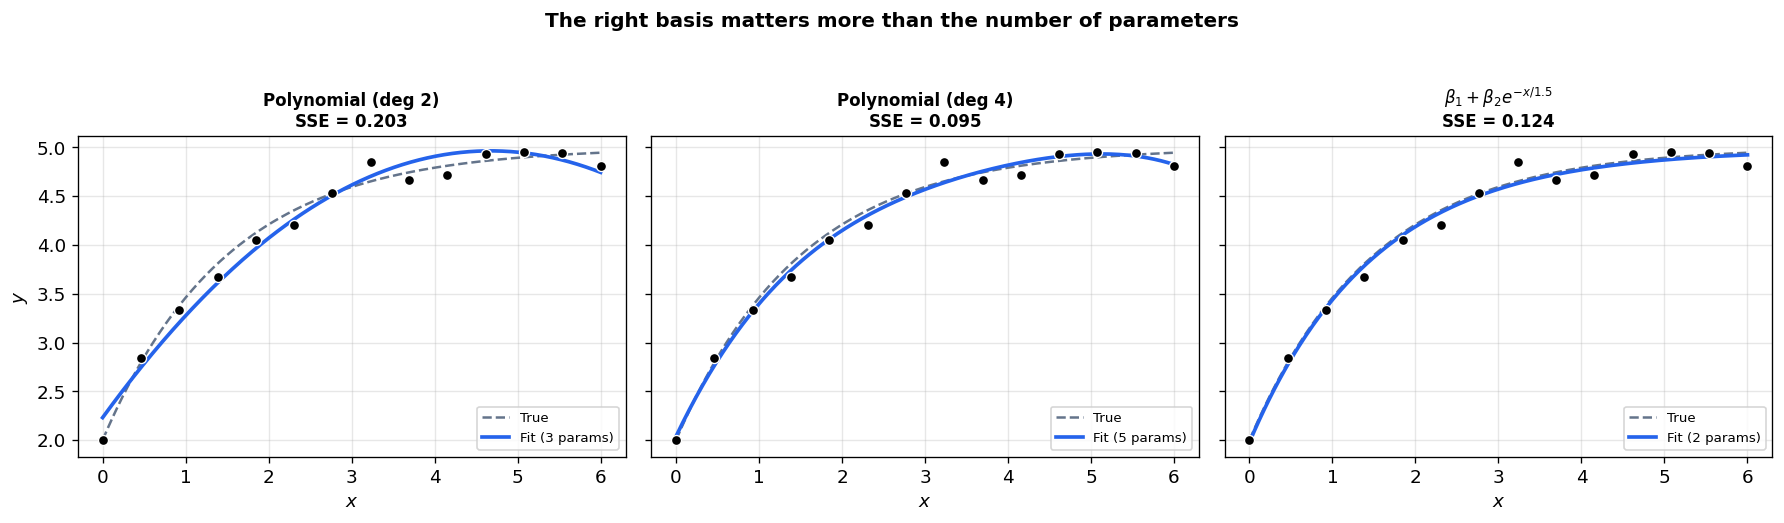

In [10]:
# Generate data from a saturating curve
def true_saturation(x):
    return 5.0 - 3.0 * np.exp(-x / 1.5)

rng2 = np.random.default_rng(seed=7)
x_sat = np.linspace(0, 6, 14)
y_sat = true_saturation(x_sat) + rng2.normal(0, 0.15, size=x_sat.size)

x_fine = np.linspace(0, 6, 300)


def design_matrix_basis(x, basis_funcs):
    "Stack a list of basis functions f_i(x) into the design matrix."
    return np.column_stack([f(x) for f in basis_funcs])


# Compare three basis choices
basis_sets = {
    "Polynomial (deg 2)":
        [lambda x: np.ones_like(x), lambda x: x, lambda x: x**2],
    "Polynomial (deg 4)":
        [lambda x: np.ones_like(x), lambda x: x, lambda x: x**2,
         lambda x: x**3, lambda x: x**4],
    r"$\beta_1 + \beta_2 e^{-x/1.5}$":
        [lambda x: np.ones_like(x), lambda x: np.exp(-x / 1.5)],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, (name, basis) in zip(axes, basis_sets.items()):
    A = design_matrix_basis(x_sat, basis)
    beta = least_squares_fit(A, y_sat)
    y_hat = A @ beta
    sse = float(np.sum((y_sat - y_hat) ** 2))

    A_fine = design_matrix_basis(x_fine, basis)
    ax.plot(x_fine, true_saturation(x_fine), color=COLORS[1], ls="--", lw=1.5,
            label="True", zorder=2)
    ax.plot(x_fine, A_fine @ beta, color=COLORS[3], lw=2.2,
            label=f"Fit ({len(beta)} params)", zorder=3)
    ax.plot(x_sat, y_sat, "o", color="black", markersize=6,
            markeredgecolor="white", markeredgewidth=0.8, zorder=5)

    ax.set_title(f"{name}\nSSE = {sse:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("$x$")
    ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylabel("$y$")
fig.suptitle("The right basis matters more than the number of parameters",
             fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()


The two-parameter exponential model fits this saturation data **better** than
a four-parameter polynomial, despite having half as many unknowns. The
take-away: pick a basis whose shape matches the underlying physics.

## 9 — Geometric Interpretation

The least-squares solution has a clean geometric meaning:

- The vector of predicted values $\hat{\mathbf{Y}} = \mathbf{A}\vec{\beta}$
  must lie in the **column space** of $\mathbf{A}$ (a linear combination of
  the basis function evaluations).
- Among all vectors in that column space, the one closest to the data $\mathbf{Y}$
  is the **orthogonal projection** of $\mathbf{Y}$ onto it.
- The residual $\vec{e} = \mathbf{Y} - \hat{\mathbf{Y}}$ is therefore
  orthogonal to every column of $\mathbf{A}$:

$$
\mathbf{A}^\top \vec{e} \;=\; \vec{0}
\qquad\Longrightarrow\qquad
\mathbf{A}^\top \mathbf{A}\,\vec{\beta} \;=\; \mathbf{A}^\top \mathbf{Y}
$$

Let us verify the orthogonality numerically with a degree-2 fit on the data
from Section 2.

In [11]:
A = design_matrix_polynomial(x_data, degree=2)
beta = least_squares_fit(A, y_data)
e = y_data - A @ beta

# A^T e should be (numerically) zero
ATe = A.T @ e
print("A^T e  (should be the zero vector up to round-off):")
for i, val in enumerate(ATe):
    print(f"    component {i}:  {val:+.2e}")

print()
print(f"||A^T e|| = {np.linalg.norm(ATe):.2e}")
print(f"||e||     = {np.linalg.norm(e):.4f}")
print()
print("The residual vector is orthogonal to every column of the design matrix.")
print("Equivalently: the residual is the part of Y that the model could not explain.")


A^T e  (should be the zero vector up to round-off):
    component 0:  -5.55e-16
    component 1:  +8.88e-15
    component 2:  -8.35e-14

||A^T e|| = 8.40e-14
||e||     = 1.1336

The residual vector is orthogonal to every column of the design matrix.
Equivalently: the residual is the part of Y that the model could not explain.


## 10 — Practical Comparison: Choosing the Right Number of Parameters

How does the SSE evolve as we add parameters? And — more importantly — does
the fit actually get *better*, or just hug the noise?

We compare on a fresh, larger data set so we can see the trend clearly.

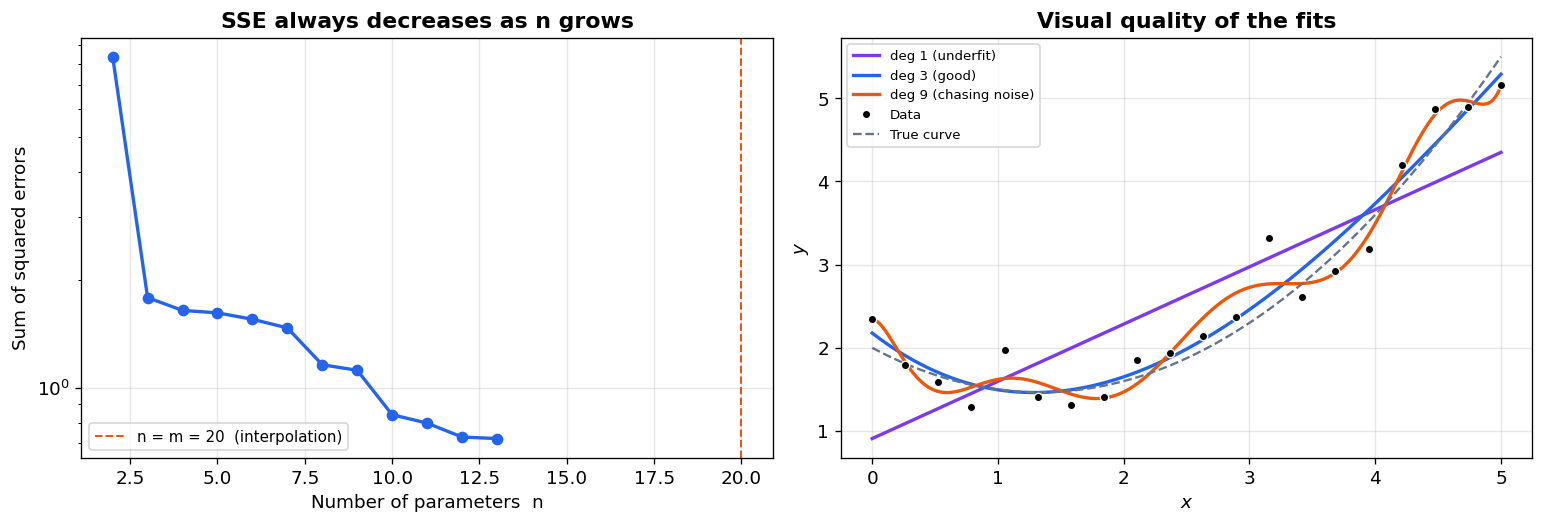

In [12]:
# Larger data set so the trend is visible
x_big, y_big = make_noisy_data(n_points=20, x_range=(0, 5), sigma=0.4)

degrees = list(range(1, 13))
sse_train = []

for deg in degrees:
    A = design_matrix_polynomial(x_big, degree=deg)
    beta = least_squares_fit(A, y_big)
    y_hat = A @ beta
    sse_train.append(np.sum((y_big - y_hat) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.semilogy([d + 1 for d in degrees], sse_train, "o-",
            color=COLORS[3], lw=2, markersize=6)
ax.axvline(len(x_big), color=COLORS[4], ls="--", lw=1.2,
           label=f"n = m = {len(x_big)}  (interpolation)")
ax.set_xlabel("Number of parameters  n")
ax.set_ylabel("Sum of squared errors")
ax.set_title("SSE always decreases as n grows", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
x_fine = np.linspace(0, 5, 400)
for deg, col, lab in zip([1, 3, 9],
                          [COLORS[2], COLORS[3], COLORS[4]],
                          ["deg 1 (underfit)", "deg 3 (good)", "deg 9 (chasing noise)"]):
    A = design_matrix_polynomial(x_big, degree=deg)
    beta = least_squares_fit(A, y_big)
    A_fine = design_matrix_polynomial(x_fine, degree=deg)
    ax.plot(x_fine, A_fine @ beta, color=col, lw=2, label=lab)
ax.plot(x_big, y_big, "o", color="black", markersize=5,
        markeredgecolor="white", markeredgewidth=0.8, zorder=5, label="Data")
ax.plot(x_fine, true_function(x_fine), color=COLORS[1], ls="--", lw=1.4,
        label="True curve")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Visual quality of the fits", fontweight="bold")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()


SSE drops monotonically as we add parameters, but the **visual quality** of
the fit peaks somewhere in the middle. A high-degree polynomial drives SSE
toward zero by tracking every random wiggle in the noise — that is *not*
a better model of the underlying physics, just a better memorisation of the
data set we happen to have.

## 11 — Notes for Students

### Key take-aways

1. **Regression $\neq$ interpolation.** Regression deliberately uses *fewer*
   coefficients than data points, so the model cannot pass through every
   point. Interpolation is the limiting case $n = m$ — and at that limit, the
   sum of squared errors collapses to zero.

2. **The normal equations are universal.** $\mathbf{A}^\top \mathbf{A}\,\vec{\beta} =
   \mathbf{A}^\top \mathbf{Y}$ holds for any choice of basis functions, as
   long as the unknown coefficients $\beta_i$ enter the model **linearly**.
   The $f_i(x)$ themselves can be polynomials, exponentials, sines, splines,
   or anything else.

3. **A model with an intercept always sums residuals to zero.** Every
   positive miss is balanced by a negative miss. This follows directly from
   the first row of the normal equations whenever the constant function
   $f_1(x) \equiv 1$ is among the basis functions.

4. **Smaller SSE is not always a better model.** Adding parameters always
   reduces (or preserves) SSE on the training data. But beyond a certain
   point, the extra flexibility is spent chasing noise — the fit becomes
   worse on *new* data even though SSE on the *given* data keeps dropping.

5. **Geometry $=$ calculus $=$ linear algebra.** Setting $\partial E /
   \partial \beta_i = 0$, projecting $\mathbf{Y}$ onto the column space of
   $\mathbf{A}$, and solving $\mathbf{A}^\top \mathbf{A}\,\vec{\beta} =
   \mathbf{A}^\top \mathbf{Y}$ are three views of the same minimum.

6. **Choosing the basis is engineering, not maths.** A two-parameter
   exponential can outperform a ten-parameter polynomial when the underlying
   physics is exponential. Always look at the data before picking a model
   form.